In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [91]:
current_df = pd.read_csv("LV Currents-data-as-joinbyfield-2026-09-12 13_01_46.csv", na_values=["undefined"])
voltage_df = pd.read_csv("LV Battery Voltage-data-2026-09-12 13_01_30.csv", na_values=["undefined"])

current_df = current_df.sort_values("time").reset_index(drop=True)
voltage_df = voltage_df.sort_values("time").reset_index(drop=True)

In [92]:
# Each current channel lands on its own row a few ms apart, so collapse each
# burst of readings into one row. A new burst starts whenever the gap to the
# previous reading exceeds BURST_GAP_MS (bursts span ~25 ms, gaps between them ~150 ms).
BURST_GAP_MS = 50

current_cols = [c for c in current_df.columns if c != "time"]
burst = (current_df["time"].diff() > BURST_GAP_MS).cumsum()

current_condensed = (
    current_df.groupby(burst)
    .agg({"time": "first", **{c: "first" for c in current_cols}})
    .reset_index(drop=True)
)

print(f"{len(current_df)} rows -> {len(current_condensed)} rows")
print(current_condensed[current_cols].notna().mean().round(3))

206501 rows -> 19694 rows
Dashboard Current           0.970
Brake Current               0.976
Shutdown Current            0.964
LV Boards Current           0.969
Radfan Current              0.968
Batt Fan Current            0.971
Pump One Current            0.968
Pump Two Current            0.966
Battbox Current             0.972
Motor Controller Current    0.960
Spare eFuse Current         0.974
dtype: float64


In [93]:
# Voltage samples every ~117 ms, independent of the current bursts, so attach the
# nearest voltage reading within MERGE_TOLERANCE_MS instead of requiring an exact match.
MERGE_TOLERANCE_MS = 100

df = pd.merge_asof(
    current_condensed,
    voltage_df,
    on="time",
    direction="nearest",
    tolerance=MERGE_TOLERANCE_MS,
)

df["time"] = pd.to_datetime(df["time"], unit="ms").dt.tz_localize("UTC").dt.tz_convert("America/New_York")

print(f"{len(df)} rows, {df['voltage'].notna().mean():.1%} with a voltage match")
df.head()

19694 rows, 95.4% with a voltage match


,time,Dashboard Current,Brake Current,Shutdown Current,LV Boards Current,Radfan Current,Batt Fan Current,Pump One Current,Pump Two Current,Battbox Current,Motor Controller Current,Spare eFuse Current,voltage
0,2026-08-15 16:20:00.273000-04:00,0.290,0.009,0.032,0.365,0.035,0.075,0.041,0.039,0.168,0.425,0.0,25.847
1,2026-08-15 16:20:00.468000-04:00,0.268,0.009,0.032,0.365,0.035,0.073,0.039,0.041,0.168,0.424,0.0,25.847
2,2026-08-15 16:20:00.616000-04:00,0.062,0.009,0.030,0.365,0.035,0.071,0.039,0.041,0.167,0.422,0.0,25.892
3,2026-08-15 16:20:00.773000-04:00,0.343,0.009,0.030,0.365,0.035,0.073,0.039,0.041,0.167,0.417,0.0,25.892
4,2026-08-15 16:20:00.927000-04:00,0.378,0.009,0.030,0.365,0.035,0.068,0.039,0.041,0.167,0.418,0.0,25.892


In [94]:
df.interpolate(method="linear", inplace=True, limit_direction="both")

,time,Dashboard Current,Brake Current,Shutdown Current,LV Boards Current,Radfan Current,Batt Fan Current,Pump One Current,Pump Two Current,Battbox Current,Motor Controller Current,Spare eFuse Current,voltage
0,2026-08-15 16:20:00.273000-04:00,0.290,0.009,0.032,0.365,0.035,0.075,0.041,0.039,0.168,0.425,0.0,25.847
1,2026-08-15 16:20:00.468000-04:00,0.268,0.009,0.032,0.365,0.035,0.073,0.039,0.041,0.168,0.424,0.0,25.847
2,2026-08-15 16:20:00.616000-04:00,0.062,0.009,0.030,0.365,0.035,0.071,0.039,0.041,0.167,0.422,0.0,25.892
3,2026-08-15 16:20:00.773000-04:00,0.343,0.009,0.030,0.365,0.035,0.073,0.039,0.041,0.167,0.417,0.0,25.892
4,2026-08-15 16:20:00.927000-04:00,0.378,0.009,0.030,0.365,0.035,0.068,0.039,0.041,0.167,0.418,0.0,25.892
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19689,2026-08-15 17:04:59.386000-04:00,0.285,0.010,0.030,0.362,0.034,2.704,0.031,0.040,0.174,0.421,0.0,24.688
19690,2026-08-15 17:04:59.509000-04:00,0.621,0.010,0.030,0.362,0.034,2.738,0.042,0.041,0.174,0.431,0.0,24.688
19691,2026-08-15 17:04:59.631000-04:00,0.481,0.010,0.030,0.362,0.036,2.682,0.040,0.039,0.174,0.424,0.0,24.688
19692,2026-08-15 17:04:59.772000-04:00,0.549,0.010,0.030,0.362,0.036,3.614,0.041,0.039,0.174,0.422,0.0,24.688


In [95]:
CURRENT_COLS_24V = [c for c in current_cols if c != "Motor Controller Current"]

df["Total Current"] = df[CURRENT_COLS_24V].sum(axis=1) + 2 * df["Motor Controller Current"]/0.9
df.head()

,time,Dashboard Current,Brake Current,Shutdown Current,LV Boards Current,Radfan Current,Batt Fan Current,Pump One Current,Pump Two Current,Battbox Current,Motor Controller Current,Spare eFuse Current,voltage,Total Current
0,2026-08-15 16:20:00.273000-04:00,0.290,0.009,0.032,0.365,0.035,0.075,0.041,0.039,0.168,0.425,0.0,25.847,1.998444
1,2026-08-15 16:20:00.468000-04:00,0.268,0.009,0.032,0.365,0.035,0.073,0.039,0.041,0.168,0.424,0.0,25.847,1.972222
2,2026-08-15 16:20:00.616000-04:00,0.062,0.009,0.030,0.365,0.035,0.071,0.039,0.041,0.167,0.422,0.0,25.892,1.756778
3,2026-08-15 16:20:00.773000-04:00,0.343,0.009,0.030,0.365,0.035,0.073,0.039,0.041,0.167,0.417,0.0,25.892,2.028667
4,2026-08-15 16:20:00.927000-04:00,0.378,0.009,0.030,0.365,0.035,0.068,0.039,0.041,0.167,0.418,0.0,25.892,2.060889


In [96]:
dAh = 0.5 * df["Total Current"] * df["time"].diff().dt.total_seconds() / 3600
df["Amp Hours"] = dAh.cumsum().fillna(0)
df["Amp Hours"].head()

0    0.000000
1    0.000053
2    0.000090
3    0.000134
4    0.000178
Name: Amp Hours, dtype: float64

In [97]:
df["Power"] = df["voltage"] * df["Total Current"]

dE = 0.5 * df["Power"] * df["time"].diff().dt.total_seconds() / 3600
df["Energy"] = dE.cumsum().fillna(0)

In [98]:
elapsed_time = (df["time"] - df["time"].iloc[0]).dt.total_seconds() / 60
print(elapsed_time.head())

0    0.000000
1    0.003250
2    0.005717
3    0.008333
4    0.010900
Name: time, dtype: float64


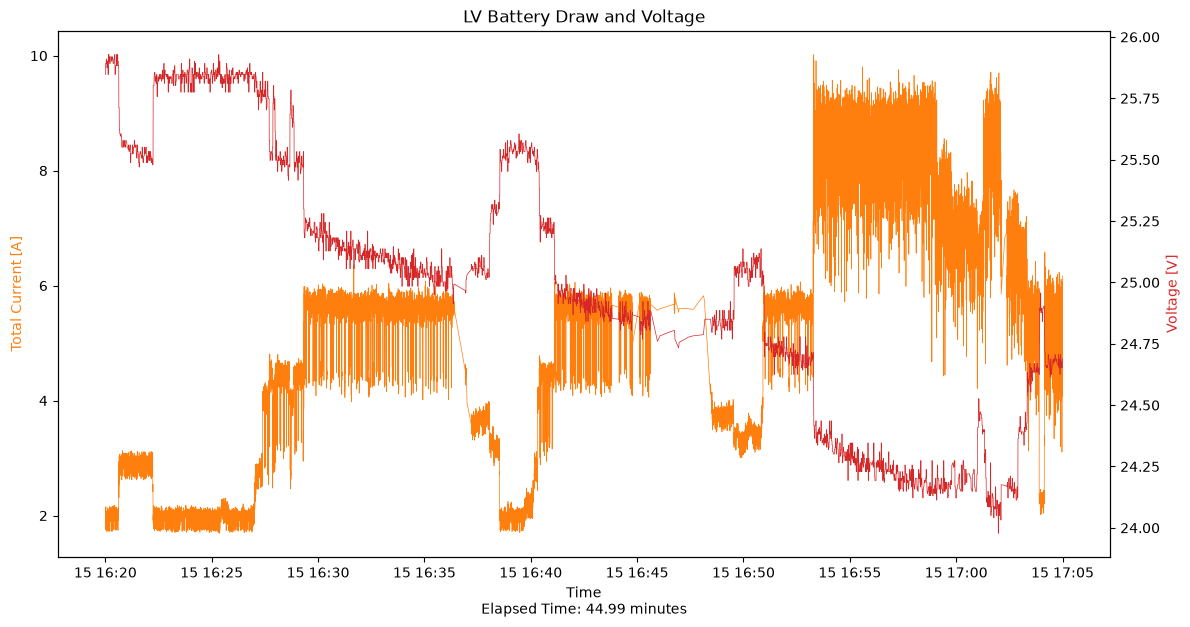

In [99]:
fig, ax1 = plt.subplots()
fig.set_size_inches(12, 6)

color1 = "tab:orange"
ax1.set_xlabel("Time")
ax1.set_ylabel("Total Current [A]", color=color1)
ax1.plot(df["time"], df["Total Current"], color=color1, lw=0.5)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Voltage [V]", color=color2)
ax2.plot(df["time"], df["voltage"], color=color2, lw=0.5)

fig.tight_layout()
plt.title("LV Battery Draw and Voltage")
plt.text(0.5, -0.1, f"Elapsed Time: {elapsed_time.iloc[-1]:.2f} minutes", ha="center", va="center", transform=ax1.transAxes)
plt.show()

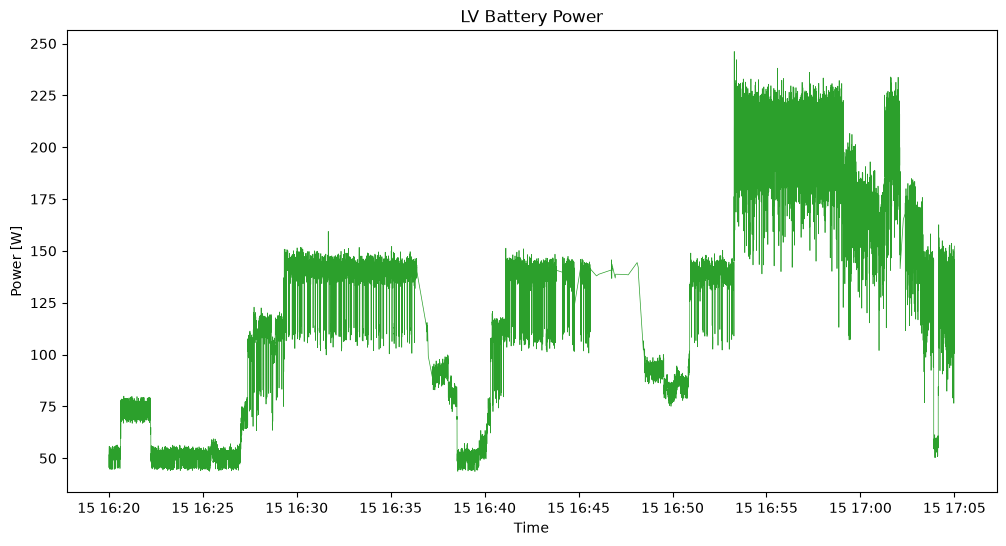

In [102]:
plt.Figure()
plt.figure(figsize=(12, 6))
plt.plot(df["time"], df["Power"], label="Power", color="tab:green", lw=0.5)
plt.xlabel("Time")
plt.ylabel("Power [W]")
plt.title("LV Battery Power")
plt.show()

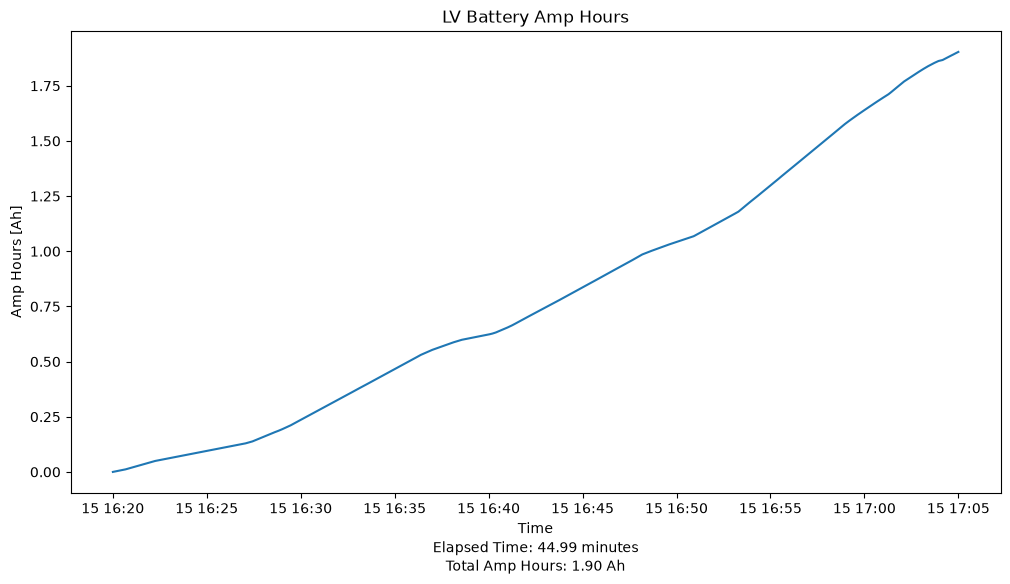

In [108]:
plt.Figure()
plt.figure(figsize=(12, 6))
plt.plot(df["time"], df["Amp Hours"], label="Amp Hours", color="tab:blue")
plt.xlabel("Time")
plt.ylabel("Amp Hours [Ah]")
plt.title("LV Battery Amp Hours")
plt.text(0.5, -0.12, f"Elapsed Time: {elapsed_time.iloc[-1]:.2f} minutes", ha="center", va="center", transform=plt.gca().transAxes)
plt.text(0.5, -0.16, f"Total Amp Hours: {df['Amp Hours'].iloc[-1]:.2f} Ah", ha="center", va="center", transform=plt.gca().transAxes)
plt.show()